# Multi-View Image Feature Aggregation 시각화

SparseNeuS식 multi-view feature aggregation(mean + variance)을 M2Mapping 데이터에 적용해 시각화한다.

- **샘플링**: 학습과 동일하게 LiDAR depth 점(`depths/*.ply`)을 `depth_pose`로 world 변환해 사용
- **투영**: 각 점을 color frame들에 brute-force 투영 (mesher.cpp와 동일한 방식)
- **aggregation**: visibility 마스크로 bilinear 샘플 후 mean / variance / coverage 집계
- **시각화**: top-down splat 렌더를 PIL 인라인 표시 (matplotlib 불필요)

의존성: `numpy`, `PIL` 만.

In [5]:
import numpy as np, glob, os, re
from PIL import Image

# ===== Config =====
ROOT = "/home/dev/jkpark/M2Mapping/data/iae_map"   # repo data symlink -> iae_5f/map_0410

# intrinsics (config/scene/config.yaml)
fx, fy, cx, cy = 580.9368694958202, 580.8762078586867, 599.8374474091759, 327.7756256909918
W, H = 1280, 720

# 샘플링 파라미터 (mv_aggregate.py와 동일)
N_PLY    = 120    # 점을 뽑을 depth 프레임 수
PTS_PER  = 700    # ply당 무작위 점 수
N_FRAMES = 250    # 투영에 쓸 color 프레임 수 (균등 샘플)

np.random.seed(0)

In [6]:
# ===== Helpers =====
def numkey(p):
    return int(re.search(r"(\d+)", os.path.basename(p)).group(1))

def read_ply(p):
    """PCL ascii ply에서 vertex element의 xyz만 반환 (뒤따르는 camera element 무시)."""
    f = open(p, "rb"); h = b""
    while b"end_header" not in h:
        h += f.readline()
    t = h.decode("ascii", "ignore")
    n = int(re.search(r"element vertex (\d+)", t).group(1))
    skip = t[:t.find("end_header")].count("\n") + 1
    return np.loadtxt(p, skiprows=skip, max_rows=n, usecols=(0, 1, 2)).reshape(n, 3)

def bilinear_sample(img, u, v):
    """img:[H,W,C] float, u,v: pixel coords [N]. 밖이면 0(padding zeros). 반환 feat[N,C], valid[N]."""
    Hh, Ww, C = img.shape
    x0 = np.floor(u).astype(int); y0 = np.floor(v).astype(int)
    x1 = x0 + 1; y1 = y0 + 1
    valid = (u >= 0) & (u <= Ww - 1) & (v >= 0) & (v <= Hh - 1)
    x0c, x1c = np.clip(x0, 0, Ww - 1), np.clip(x1, 0, Ww - 1)
    y0c, y1c = np.clip(y0, 0, Hh - 1), np.clip(y1, 0, Hh - 1)
    wx = (u - x0)[:, None]; wy = (v - y0)[:, None]
    f = (img[y0c, x0c] * (1 - wx) * (1 - wy) + img[y0c, x1c] * wx * (1 - wy) +
         img[y1c, x0c] * (1 - wx) * wy + img[y1c, x1c] * wx * wy)
    f[~valid] = 0
    return f, valid

def turbo(x):
    """x in [0,1] -> RGB [N,3] 0..255 (간이 jet)."""
    x = np.clip(x, 0, 1)
    r = np.clip(1.5 - np.abs(4 * x - 3), 0, 1)
    g = np.clip(1.5 - np.abs(4 * x - 2), 0, 1)
    b = np.clip(1.5 - np.abs(4 * x - 1), 0, 1)
    return np.stack([r, g, b], 1) * 255

def render_topdown(xyz, rgb, RES=900, ps=1):
    """top-down(XY) splat 렌더 -> PIL.Image. 높은 z를 위에 그림."""
    x, y, z = xyz[:, 0], xyz[:, 1], xyz[:, 2]
    x0, x1, y0, y1 = x.min(), x.max(), y.min(), y.max()
    s = min((RES - 20) / (x1 - x0), (RES - 20) / (y1 - y0))
    px = np.clip(((x - x0) * s + 10).astype(int), 0, RES - 1)
    py = np.clip((RES - 1 - ((y - y0) * s + 10)).astype(int), 0, RES - 1)
    img = np.zeros((RES, RES, 3), np.uint8)
    zbuf = np.full((RES, RES), -1e9)
    rgb = np.clip(rgb, 0, 255).astype(np.uint8)
    for i in np.argsort(z):
        a, b = py[i], px[i]
        for dy in range(-ps, ps + 1):
            for dx in range(-ps, ps + 1):
                yy, xx = a + dy, b + dx
                if 0 <= yy < RES and 0 <= xx < RES and z[i] > zbuf[yy, xx]:
                    img[yy, xx] = rgb[i]; zbuf[yy, xx] = z[i]
    return Image.fromarray(img)

def write_ply(path, xyz, rgb):
    rgb = np.clip(rgb, 0, 255).astype(np.uint8)
    with open(path, "w") as f:
        f.write(f"ply\nformat ascii 1.0\nelement vertex {len(xyz)}\n")
        f.write("property float x\nproperty float y\nproperty float z\n")
        f.write("property uchar red\nproperty uchar green\nproperty uchar blue\nend_header\n")
        for p, c in zip(xyz, rgb):
            f.write(f"{p[0]:.4f} {p[1]:.4f} {p[2]:.4f} {c[0]} {c[1]} {c[2]}\n")
    print("wrote", path)

In [7]:
# ===== 1. LiDAR 점 샘플 (학습과 동일 방식) =====
cp = np.loadtxt(f"{ROOT}/color_poses.txt").reshape(-1, 4, 4)   # camera c2w
dp = np.loadtxt(f"{ROOT}/depth_poses.txt").reshape(-1, 4, 4)   # lidar  c2w
plys = sorted(glob.glob(f"{ROOT}/depths/*.ply"), key=numkey)
imgs = {numkey(p): p for p in glob.glob(f"{ROOT}/images/*.png")}
img_keys = sorted(imgs)
print(f"color frames {len(cp)}, depth frames {len(dp)}, plys {len(plys)}, images {len(img_keys)}")

pts = []
for k in np.linspace(0, len(plys) - 1, N_PLY).astype(int):
    pc = read_ply(plys[k])
    if len(pc) == 0:
        continue
    pc = pc[np.random.choice(len(pc), min(PTS_PER, len(pc)), replace=False)]
    T = dp[k]                                  # local(sensor) -> world
    pc = (T[:3, :3] @ pc.T).T + T[:3, 3]
    pts.append(pc)
X = np.concatenate(pts, 0); N = len(X)
Xh = np.concatenate([X, np.ones((N, 1))], 1)
print(f"sampled {N} points, world-range {X.min(0).round(1)} ~ {X.max(0).round(1)}")

color frames 2101, depth frames 2102, plys 2102, images 2101
sampled 84000 points, world-range [-14.3 -40.6  -9.4] ~ [62.8 15.6  2.7]


In [12]:
frame_sel.shape

(250,)

In [8]:
# ===== 2. Multi-view aggregation (mean + variance + coverage) =====
frame_sel = np.linspace(0, min(len(cp), len(img_keys)) - 1, N_FRAMES).astype(int)
C = 3                                           # feature dim (RGB). DINO/CNN으로 교체 가능
sum_f = np.zeros((N, C)); sum_sq = np.zeros((N, C)); cnt = np.zeros(N)

for j, i in enumerate(frame_sel):
    img = np.asarray(Image.open(imgs[img_keys[i]]).convert("RGB"), np.float32) / 255.0
    w2c = np.linalg.inv(cp[i])
    cam = (w2c @ Xh.T).T[:, :3]
    z = cam[:, 2]; zs = np.where(np.abs(z) < 1e-9, 1e-9, z)
    u = fx * cam[:, 0] / zs + cx
    v = fy * cam[:, 1] / zs + cy
    front = z > 0
    feat, vin = bilinear_sample(img, u, v)
    m = front & vin                              # visibility (frustum + z>0)
    sum_f[m] += feat[m]; sum_sq[m] += feat[m] ** 2; cnt[m] += 1
    if (j + 1) % 50 == 0:
        print(f"  {j+1}/{N_FRAMES} frames")

# --- SparseNeuS aggregate_multiview_features: mean + variance, masked ---
denom = np.clip(cnt, 1, None)[:, None]
mean = sum_f / denom
var = np.clip(sum_sq / denom - mean ** 2, 0, None)
valid = cnt > 0                                  # no-coverage -> False (예외처리 대상)
var_mag = var.mean(1)

print(f"\nvalid(>=1 view): {valid.mean()*100:.1f}%   mean views/pt: {cnt[valid].mean():.1f}")
print(f"variance: min {var_mag[valid].min():.4f}  median {np.median(var_mag[valid]):.4f}  max {var_mag[valid].max():.4f}")

  50/250 frames
  100/250 frames
  150/250 frames
  200/250 frames
  250/250 frames

valid(>=1 view): 100.0%   mean views/pt: 66.8
variance: min 0.0140  median 0.0589  max 0.1659


## 시각화
각 셀의 마지막 줄이 `PIL.Image`라 노트북에 인라인 표시된다.

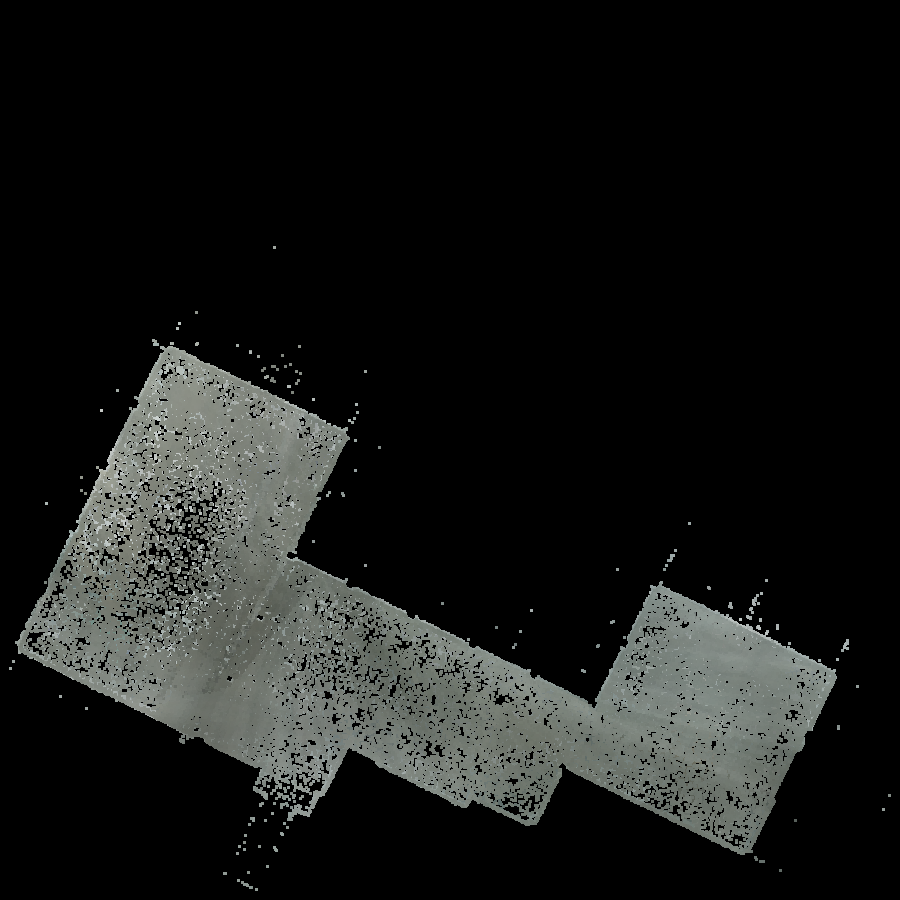

In [9]:
# (1) mean RGB : multi-view 평균 색 -> 투영/정합 검증
render_topdown(X, mean * 255)

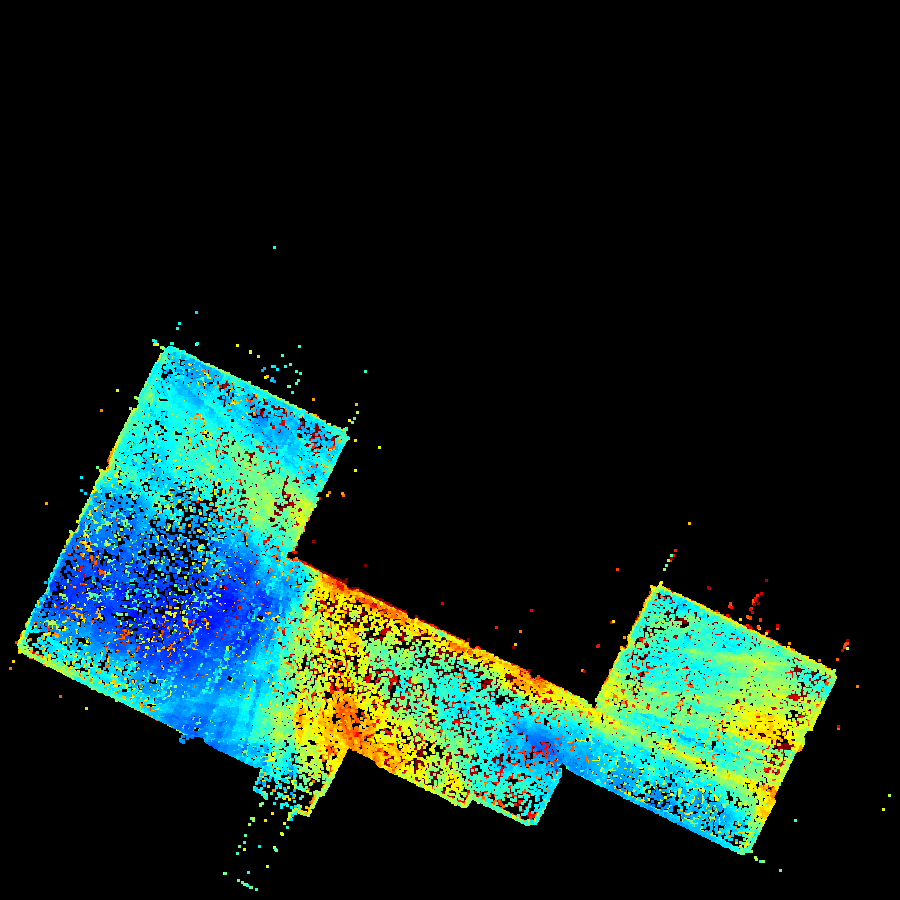

In [10]:
# (2) variance : view간 색 불일치 (파랑=일치/표면, 빨강=불일치/occlusion·specular)
vnorm = var_mag / (np.percentile(var_mag[valid], 95) + 1e-9)
render_topdown(X, turbo(vnorm))

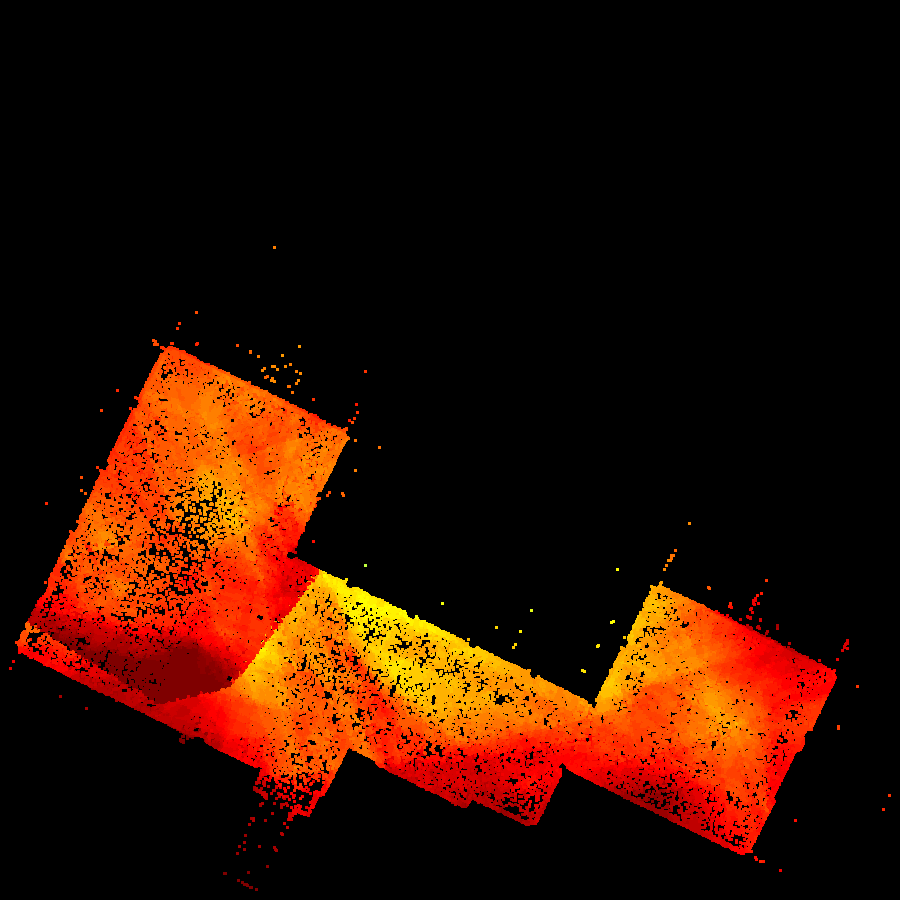

In [11]:
# (3) coverage : 본 view 수 (노랑=많음)
cnorm = cnt / np.percentile(cnt[valid], 95)
render_topdown(X, turbo(cnorm))

In [ ]:
# (선택) PLY로 저장해 외부 뷰어(meshlab/vedo)에서 3D 확인
OUT = os.path.dirname(os.path.abspath("mv_feature_viz.ipynb"))
write_ply(f"{OUT}/agg_mean_rgb.ply", X, mean * 255)
write_ply(f"{OUT}/agg_variance.ply", X, turbo(vnorm))
write_ply(f"{OUT}/agg_coverage.ply", X, turbo(cnorm))